# Yield Curve PCA


Let: 

$$
y_t =
\begin{bmatrix}
y_t(\tau_1) \\
y_t(\tau_2) \\
\vdots \\
y_t(\tau_n)
\end{bmatrix}
$$

$y_t(\tau_i)$: yield at time $ t $ and maturity $\tau_i$  
$n$: number of maturities  

Compute the covariance matrix:

$$
\Sigma = \mathrm{Cov}(y_t)
$$


PCA is based on decomposition:

$$
\Sigma = V \Lambda V^\top
$$

Where:

$V$: matrix of eigenvectors (principal components)  
$\Lambda$: diagonal matrix of eigenvalues  

The principal components are:

$$
PC_t = V^\top y_t
$$

$ PC_t$: vector of factor realizations at time $ t $  , each component is uncorrelated with others  


Yield curve is approximated with the first $ k $ components:

$$
y_t \approx \sum_{i=1}^{k} PC_{t}^{(i)} \cdot v^{(i)}
$$


first component - Level (PC1)
- Nearly equal loadings across maturities  
- Represents **parallel shifts** of the yield curve  

second component - Slope (PC2)
- Positive loadings at short maturities, negative at long (or vice versa)  
- Represents **steepening / flattening**  

third component - Curvature (PC3)
- Positive in the middle, negative at ends  
- Represents **hump-shaped changes**  


The proportion of variance explained by component $ i $:

$$
\text{Var explained}_i = \frac{\lambda_i}{\sum_{j=1}^{n} \lambda_j}
$$

Typically:

- PC1: ~80–90%  
- PC2: ~5–15%  
- PC3: ~1–5%  


using 3 components: $y_t(\tau) \approx PC_{1,t} \cdot v_1(\tau) + PC_{2,t} \cdot v_2(\tau) + PC_{3,t} \cdot v_3(\tau) $


In [37]:
#load data
#todo: load monthly data instead of daily
from pandas_datareader import data as pdr
import pandas as pd

start = "2000-01-01"

series = {
    "1Y": "DGS1",
    "2Y": "DGS2",
    "3Y": "DGS3",
    "5Y": "DGS5",
    "7Y": "DGS7",
    "10Y": "DGS10",
    "20Y": "DGS20",
    "30Y": "DGS30"
}

dfs = []

for name, code in series.items():
    tmp = pdr.DataReader(code, "fred", start)
    tmp.columns = [name]   # rename column
    dfs.append(tmp)

df = pd.concat(dfs, axis=1)

df = df.ffill()

print(df.tail())

              1Y    2Y    3Y    5Y    7Y   10Y   20Y   30Y
DATE                                                      
2026-03-27  3.77  3.88  3.94  4.06  4.25  4.44  4.99  4.98
2026-03-30  3.71  3.82  3.85  3.97  4.16  4.35  4.92  4.91
2026-03-31  3.68  3.79  3.81  3.92  4.11  4.30  4.88  4.88
2026-04-01  3.68  3.81  3.84  3.97  4.15  4.33  4.91  4.91
2026-04-02  3.68  3.79  3.82  3.94  4.12  4.31  4.88  4.88


In [38]:
import pandas as pd

# Use changes to focus on co-movement
df_diff = df.diff().dropna()

# Correlation matrix
corr = df_diff.corr()

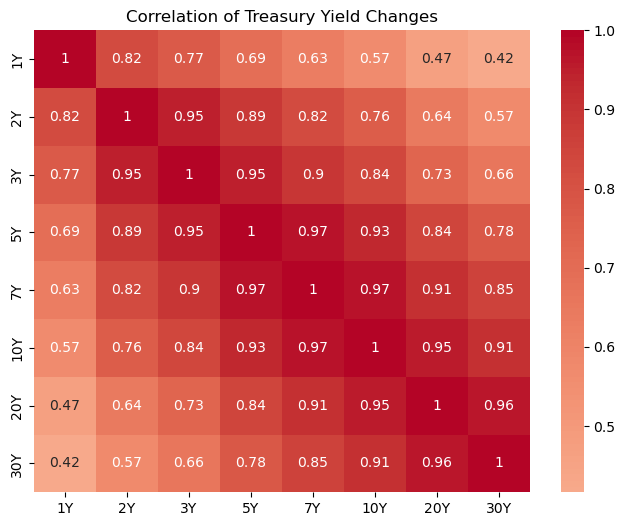

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation of Treasury Yield Changes")
plt.show()

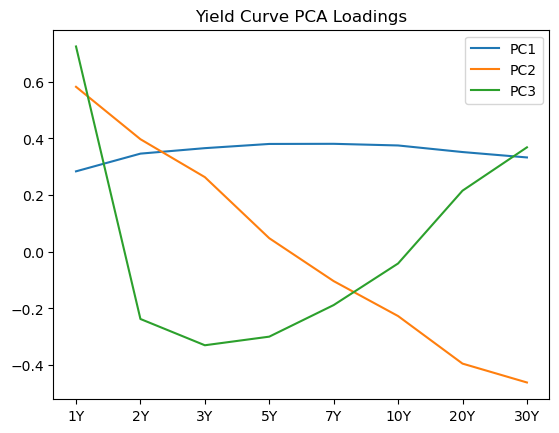

In [40]:
import numpy as np
from sklearn.decomposition import PCA

# daily changes
X = df.diff().dropna()

# standardize 
X_std = (X - X.mean()) / X.std()

pca = PCA(n_components=3)
pca.fit(X_std)

components = pca.components_
explained = pca.explained_variance_ratio_
#viz
import matplotlib.pyplot as plt

maturities = list(series.keys())

for i, comp in enumerate(components):
    plt.plot(maturities, comp, label=f"PC{i+1}")

plt.legend()
plt.title("Yield Curve PCA Loadings")
plt.show()

#todo: show scree plot

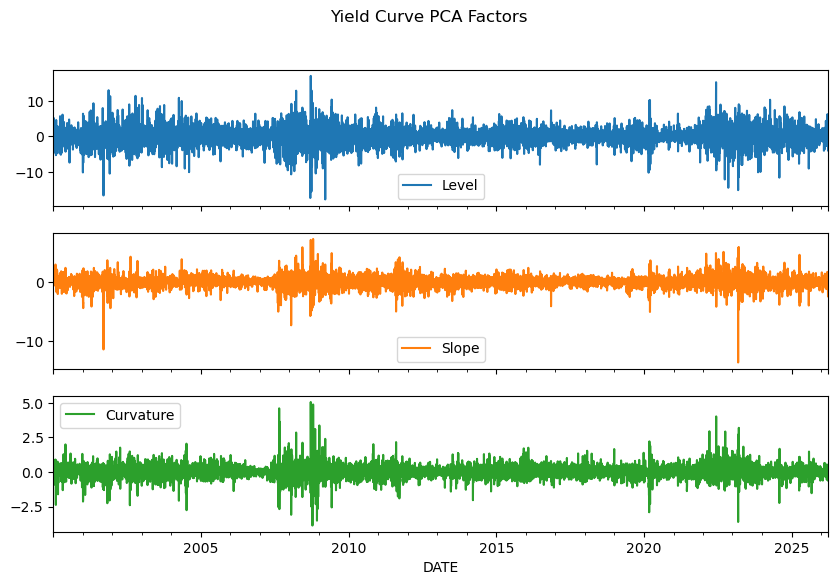

In [23]:
#extract factor time series
factors = pca.transform(X_std)

factors = pd.DataFrame(
    factors,
    index=X_std.index,
    columns=["Level", "Slope", "Curvature"]
)

import matplotlib.pyplot as plt

factors.plot(subplots=True, figsize=(10, 6), title="Yield Curve PCA Factors")
plt.show()

# Forecasting Yield Curve PCA Factors with ARIMA / ARMA


factor time series:

$$
PC_t =
\begin{bmatrix}
PC_{1,t} \\
PC_{2,t} \\
PC_{3,t}
\end{bmatrix}
$$

Each factor is modeled as a univariate time series:

$$
PC_{i,t} = \phi_1 PC_{i,t-1} + \cdots + \theta_1 \varepsilon_{t-1} + \varepsilon_t
$$


The one-step ahead forecast

$$
\widehat{PC}_{i,t+1} = \mathbb{E}[PC_{i,t+1} \mid \mathcal{F}_t]
$$

yield curve forecast:

$$
\widehat{y}_{t+1} = V_k \cdot \widehat{PC}_{t+1}
$$


# Exercises

## 1. Nelson–Siegel Model

The Nelson–Siegel model provides a **parsimonious parametric representation** of the yield curve.

The yield at maturity \( \tau \) is modeled as:

$$
y(\tau) = \beta_0 + \beta_1 \cdot \frac{1 - e^{-\lambda \tau}}{\lambda \tau}
+ \beta_2 \cdot \left( \frac{1 - e^{-\lambda \tau}}{\lambda \tau} - e^{-\lambda \tau} \right)
$$

where

$ \beta_0$: **Level**  - Long-term component (affects all maturities equally)

$  \beta_1$: **Slope**  - Controls short vs long rates, dominates short maturities  

$ \beta_2$: **Curvature**  - Controls the hump in medium maturities  

$ \lambda$: **Decay parameter**  - Controls how fast the exponential terms decay, determines location of curvature peak  


The model can be written in linear form:

$$
y(\tau) = \Lambda(\tau) \cdot \beta
$$

Where:

$$
\beta =
\begin{bmatrix}
\beta_0 \\
\beta_1 \\
\beta_2
\end{bmatrix}
$$

and the loading matrix:

$$
\Lambda(\tau) =
\begin{bmatrix}
1 & \frac{1 - e^{-\lambda \tau}}{\lambda \tau} & \frac{1 - e^{-\lambda \tau}}{\lambda \tau} - e^{-\lambda \tau}
\end{bmatrix}
$$


## 3. Diebold–Li Model

The Diebold–Li model extends Nelson–Siegel by making the factors **time-varying**.

$$
\beta_t =
\begin{bmatrix}
\beta_{0t} \\
\beta_{1t} \\
\beta_{2t}
\end{bmatrix}
$$

So the yield becomes:

$$
y_t(\tau) = \Lambda(\tau) \cdot \beta_t + \epsilon_t
$$

$ \beta_{0t}$: time-varying level  

$ \beta_{1t}$: time-varying slope  

$ \beta_{2t}$: time-varying curvature  

$ \epsilon_t$: measurement noise  


## 4. State-Space Representation

The Diebold–Li model can be written as a **state-space model**.

### Observation equation:

$$
y_t = \Lambda \beta_t + \epsilon_t, \quad \epsilon_t \sim N(0, H)
$$

$y_t$: observed yields
$\Lambda$: loading matrix
$H$: observation noise covariance  

### State equation:

$$
\beta_{t+1} = \mu + F \beta_t + \eta_t, \quad \eta_t \sim N(0, Q)
$$

$\beta_t$: latent factors (level, slope, curvature)  
$F$: transition matrix  
$ Q$: state noise covariance  
$\mu$: drift term  



In [41]:
# Debold-Li
import numpy as np

def nelson_siegel_loadings(tau, lambd=0.0609):
    L1 = np.ones_like(tau)
    L2 = (1 - np.exp(-lambd * tau)) / (lambd * tau)
    L3 = L2 - np.exp(-lambd * tau)
    return np.column_stack([L1, L2, L3])

In [42]:
from numpy.linalg import lstsq

tau = np.array([1,2,3,5,7,10,20,30])  # in years
Lambda = nelson_siegel_loadings(tau)

# df: daily yields
factors_ts = []
for _, y in df.iterrows():
    beta_hat, _, _, _ = lstsq(Lambda, y.values, rcond=None)
    factors_ts.append(beta_hat)

factors_ts = np.array(factors_ts)  # T x 3

In [43]:
from statsmodels.tsa.api import VAR

model = VAR(factors_ts)
res = model.fit(1)  # VAR(1)

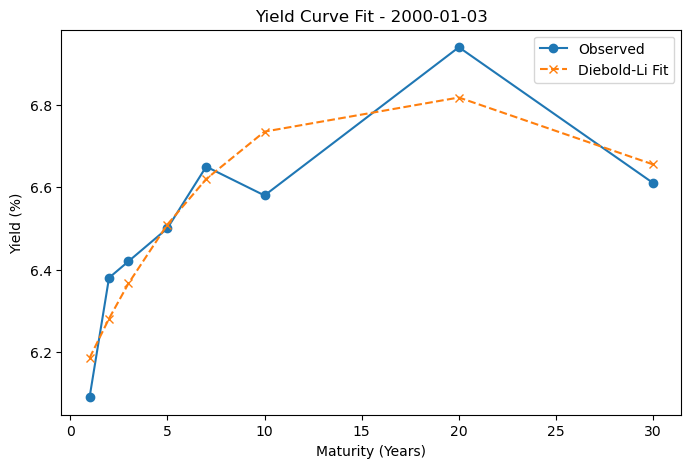

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# If df.columns = ['1Y','2Y','3Y','5Y',...]
tau = np.array([float(c.strip('Y')) for c in df.columns])
date_idx = 0
observed_yields = df.iloc[date_idx].values
fitted_yields = Lambda @ factors_ts[date_idx]


plt.figure(figsize=(8,5))
plt.plot(tau, observed_yields, 'o-', label="Observed")
plt.plot(tau, fitted_yields, 'x--', label="Diebold-Li Fit")
plt.xlabel("Maturity (Years)")
plt.ylabel("Yield (%)")
plt.title(f"Yield Curve Fit - {df.index[date_idx].date()}")
plt.legend()
plt.show()

# Yield Curve Principal Components – Example

The change in the yield of a bond (e.g., 10-year) can be approximated using principal components:

$$
\Delta y_{10Y}^{\text{PCA}} = l_{10Y}^{(1)} \cdot \Delta PC_1 + l_{10Y}^{(2)} \cdot \Delta PC_2 + l_{10Y}^{(3)} \cdot \Delta PC_3
$$

Where:

$ \Delta y_{10Y}^{\text{PCA}}$ = predicted change in 10-year yield  

$l_{10Y}^{(i)} $ = loading of the 10-year yield on the $i$-th principal component  

$\Delta PC_i $ = change in the $i$-th principal component  


Assume 10Y loadings:

$$
l_{10Y} = 
\begin{bmatrix} 0.7 \\ 0.5 \\ 0.1 \end{bmatrix}
$$

and daily PCA factor changes:

$$
\Delta PC = 
\begin{bmatrix} 0.02 \\ -0.01 \\ 0.005 \end{bmatrix}
$$

Then the predicted yield change:

$$
\Delta y_{10Y}^{\text{PCA}} 
= 0.7 \cdot 0.02 + 0.5 \cdot (-0.01) + 0.1 \cdot 0.005
= 0.0095 \quad (\text{0.95 basis points})
$$




In [1]:
import numpy as np

# PCA loadings for 10Y bond
loadings_10Y = np.array([0.7, 0.5, 0.1])

# Daily change in PCA factors
delta_PC = np.array([0.02, -0.01, 0.005])  # Level, Slope, Curvature

# Predicted yield change
delta_yield_10Y = loadings_10Y @ delta_PC
print(f"Predicted 10Y yield change: {delta_yield_10Y:.4f} = {delta_yield_10Y*100:.2f} bps")

Predicted 10Y yield change: 0.0095 = 0.95 bps


# Exercises

1. Compare PCA predictions from example to full yield curve prediction
2. Predict today's change in 5Y yield using PCA components, given Treasuery curve data
        